# Análise da população por Estado e Município

Atividade:
1. Ler a tabela do Censo Demográfico 2022.
2. Criar uma tabela de população agregada por estado.
3. Calcular a diferença de população entre 2022 e 2010 e ordenar pelo maior crescimento.
4. Salvar o resultado em CSV.
5. Fazer a mesma análise por município.
6. Salvar o resultado em CSV.

A coluna de 2010 utilizada é **População 2010 (Alterações de Limites até 2022)1**, pois a própria tabela informa que ela é compatibilizada com a base territorial de 2022.


In [1]:
from pathlib import Path
import pandas as pd

# Pasta do projeto: mesma pasta onde estão este notebook e o Excel
PASTA_PROJETO = Path.cwd()

ARQUIVO_EXCEL = PASTA_PROJETO / "CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

ARQUIVO_ESTADOS = PASTA_PROJETO / "populacao_por_estado_2010_2022.csv"

ARQUIVO_MUNICIPIOS = PASTA_PROJETO / "populacao_por_municipio_2010_2022.csv"

print("Pasta do projeto:", PASTA_PROJETO)
print("Arquivo Excel:", ARQUIVO_EXCEL)


Pasta do projeto: /mnt/data/GitNovo_work/AtividadeEstado
Arquivo Excel: /mnt/data/GitNovo_work/AtividadeEstado/CD2022_Populacao_2010_Compatibilizada_20231222.xlsx


In [2]:
# 4 - Ler a tabela
# O cabeçalho dos dados está na terceira linha da planilha.
df = pd.read_excel(ARQUIVO_EXCEL, sheet_name="Municípios", header=2)

# Remover linhas que não possuem município/UF (rodapé e observações)
df = df.dropna(subset=["UF", "NOME DO MUNICÍPIO"]).copy()

# Garantir que as colunas populacionais sejam numéricas
colunas_populacao = [
    "População Município 2010\n(Sinopse)",
    "População 2010 (Alterações de Limites até 2022)1",
    "População Censo 2022",
]

for coluna in colunas_populacao:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

df.head()


,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


## População agregada por estado

In [3]:
# 5 - Criar a tabela de população agregada por estado
# A agregação segue a estrutura: groupby + sum + reset_index.

populacao_estado = (
    df.groupby("UF")[
        [
            "População 2010 (Alterações de Limites até 2022)1",
            "População Censo 2022",
        ]
    ]
    .sum()
    .reset_index()
)

# 6 - Calcular a diferença e ordenar pelo maior crescimento
populacao_estado["Crescimento_2010_2022"] = (
    populacao_estado["População Censo 2022"]
    - populacao_estado["População 2010 (Alterações de Limites até 2022)1"]
)

populacao_estado = populacao_estado.sort_values(
    "Crescimento_2010_2022", ascending=False
).reset_index(drop=True)

populacao_estado


,UF,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,Crescimento_2010_2022
0,SP,41262199.0,44411238.0,3149039.0
1,SC,6248436.0,7610361.0,1361925.0
2,GO,6001789.0,7056495.0,1054706.0
3,PR,10444526.0,11444380.0,999854.0
4,MG,19597330.0,20539989.0,942659.0
5,MT,3035122.0,3658649.0,623527.0
6,PA,7581051.0,8120131.0,539080.0
7,AM,3483985.0,3941613.0,457628.0
8,CE,8451644.0,8794957.0,343313.0
9,ES,3514952.0,3833712.0,318760.0


In [4]:
# 7 - Salvar a tabela de estados em CSV
populacao_estado.to_csv(
    ARQUIVO_ESTADOS,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo salvo em: {ARQUIVO_ESTADOS}")


Arquivo salvo em: /mnt/data/GitNovo_work/AtividadeEstado/populacao_por_estado_2010_2022.csv


## População por município

In [5]:
# 8 e 9 - Trabalhar por município, calcular a diferença e ordenar pelo maior crescimento

populacao_municipio = df[
    [
        "UF",
        "COD. UF",
        "COD. MUNIC",
        "NOME DO MUNICÍPIO",
        "População 2010 (Alterações de Limites até 2022)1",
        "População Censo 2022",
    ]
].copy()

populacao_municipio["Crescimento_2010_2022"] = (
    populacao_municipio["População Censo 2022"]
    - populacao_municipio["População 2010 (Alterações de Limites até 2022)1"]
)

populacao_municipio = populacao_municipio.sort_values(
    "Crescimento_2010_2022", ascending=False
).reset_index(drop=True)

populacao_municipio.head(20)


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,Crescimento_2010_2022
0,AM,13.0,2603.0,Manaus,1802014.0,2063689.0,261675.0
1,DF,53.0,108.0,Brasília,2572159.0,2817381.0,245222.0
2,SP,35.0,50308.0,São Paulo,11253503.0,11451999.0,198496.0
3,SP,35.0,52205.0,Sorocaba,586816.0,723682.0,136866.0
4,GO,52.0,8707.0,Goiânia,1301912.0,1437366.0,135454.0
5,RR,14.0,100.0,Boa Vista,284313.0,413486.0,129173.0
6,SC,42.0,5407.0,Florianópolis,421240.0,537211.0,115971.0
7,PA,15.0,5536.0,Parauapebas,153908.0,267836.0,113928.0
8,MS,50.0,2704.0,Campo Grande,786774.0,898100.0,111326.0
9,PB,25.0,7507.0,João Pessoa,723515.0,833932.0,110417.0


In [6]:
# 10 - Salvar a tabela de municípios em CSV
populacao_municipio.to_csv(
    ARQUIVO_MUNICIPIOS,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo salvo em: {ARQUIVO_MUNICIPIOS}")


Arquivo salvo em: /mnt/data/GitNovo_work/AtividadeEstado/populacao_por_municipio_2010_2022.csv


In [7]:
# Conferência final
print("Arquivos gerados:")
for arquivo in [ARQUIVO_ESTADOS, ARQUIVO_MUNICIPIOS]:
    print(f"- {arquivo.name}: {arquivo.stat().st_size} bytes")

print("\n5 estados com maior crescimento absoluto:")
display(populacao_estado.head(5))

print("\n10 municípios com maior crescimento absoluto:")
display(populacao_municipio.head(10))


Arquivos gerados:
- populacao_por_estado_2010_2022.csv: 972 bytes
- populacao_por_municipio_2010_2022.csv: 281661 bytes

5 estados com maior crescimento absoluto:


,UF,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,Crescimento_2010_2022
0,SP,41262199.0,44411238.0,3149039.0
1,SC,6248436.0,7610361.0,1361925.0
2,GO,6001789.0,7056495.0,1054706.0
3,PR,10444526.0,11444380.0,999854.0
4,MG,19597330.0,20539989.0,942659.0



10 municípios com maior crescimento absoluto:


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,Crescimento_2010_2022
0,AM,13.0,2603.0,Manaus,1802014.0,2063689.0,261675.0
1,DF,53.0,108.0,Brasília,2572159.0,2817381.0,245222.0
2,SP,35.0,50308.0,São Paulo,11253503.0,11451999.0,198496.0
3,SP,35.0,52205.0,Sorocaba,586816.0,723682.0,136866.0
4,GO,52.0,8707.0,Goiânia,1301912.0,1437366.0,135454.0
5,RR,14.0,100.0,Boa Vista,284313.0,413486.0,129173.0
6,SC,42.0,5407.0,Florianópolis,421240.0,537211.0,115971.0
7,PA,15.0,5536.0,Parauapebas,153908.0,267836.0,113928.0
8,MS,50.0,2704.0,Campo Grande,786774.0,898100.0,111326.0
9,PB,25.0,7507.0,João Pessoa,723515.0,833932.0,110417.0


## Atividade 4 — População 2022 por UF

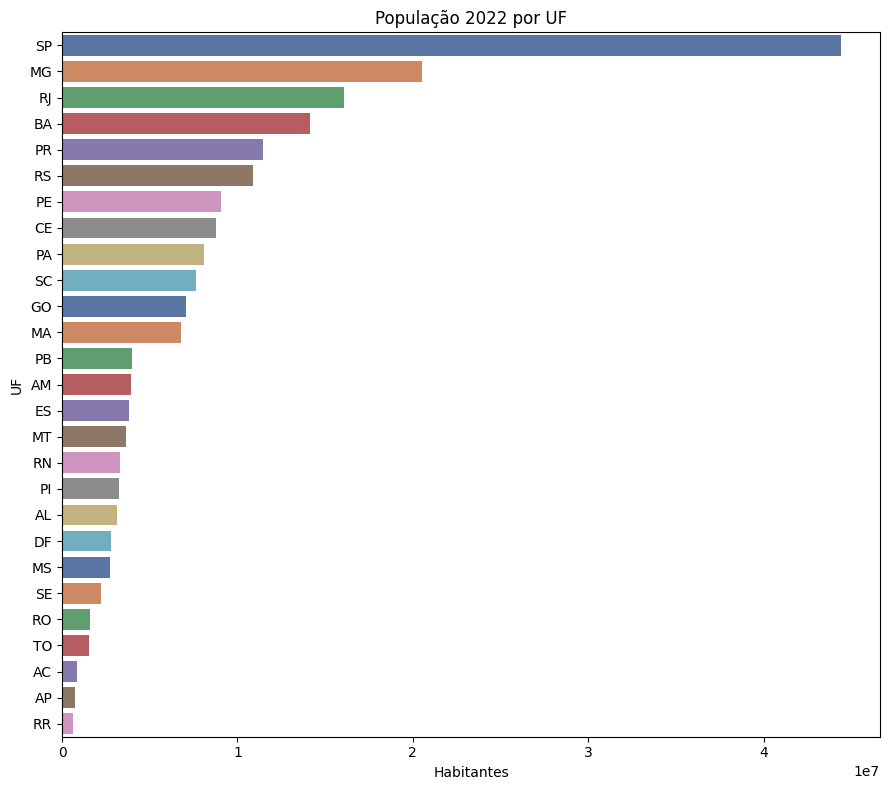

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Renomeia a coluna para deixar o código do gráfico mais simples
pop_estado = populacao_estado.rename(
    columns={"População Censo 2022": "2022"}
).copy()

ordem = pop_estado.sort_values("2022", ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=ordem, y="UF", x="2022", hue="UF", legend=False, palette="deep", ax=ax)
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()
